# Análise de Dados do YouTube — Aula 2

Neste notebook vamos analisar vídeos, canais e comentários de um conjunto de dados do YouTube.

A versão didática separa **cada visualização em seu próprio bloco de código**, de modo que você possa executar uma etapa por vez e observar a saída correspondente logo abaixo, com uma breve explicação do que cada gráfico mostra.

**Roteiro:**
1. Preparação do ambiente (montar o Drive, importar bibliotecas)
2. Carregamento e inspeção dos dados
3. Limpeza (remoção de canais duplicados)
4. Funções utilitárias e construção de métricas
5. Resumo estatístico
6. Visualizações — uma por bloco
7. Comparações por grupo


## 1. Preparação do ambiente

Montamos o Google Drive para acessar os arquivos CSV do dataset.

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

Importamos as bibliotecas que serão usadas em toda a análise: manipulação de dados (`pandas`, `numpy`), visualização (`matplotlib`, `seaborn`, `plotly`) e expressões regulares (`re`).

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import plotly.express as px
import matplotlib.pyplot as plt
import re



## 2. Carregamento dos dados

Lemos os três arquivos: comentários, vídeos e canais. Cada um vira um *DataFrame* do pandas.

In [3]:
# importa o arquivo e guarda em um dataframe do Pandas
dfcomentarios = pd.read_csv( '../fastback/fastback/comments_info.csv')
dfvideos = pd.read_csv( '../fastback/fastback/videos_info.csv')
dfcanais = pd.read_csv( '../fastback/fastback/channels_info.csv')
print('Dados importados com sucesso!')

Dados importados com sucesso!


Antes de qualquer análise, vale conhecer o **tamanho** de cada tabela (número de linhas e colunas). A função abaixo imprime essas dimensões.

In [4]:
def print_shape(name, df):
  num_linhas, num_colunas = df.shape
  print(f'{name}: \nLinhas: {num_linhas}\nColunas: {num_colunas}\n')

print_shape('Dados comentários', dfcomentarios)
print_shape('Dados vídeos', dfvideos)
print_shape('Dados canais', dfcanais)

Dados comentários: 
Linhas: 4199
Colunas: 15

Dados vídeos: 
Linhas: 34
Colunas: 35

Dados canais: 
Linhas: 34
Colunas: 12



## 3. Limpeza: removendo canais duplicados

O arquivo de canais repete o mesmo `channel_id` várias vezes (um registro por vídeo associado). Para análises por canal, mantemos apenas a **primeira ocorrência** de cada `channel_id` e geramos um relatório das duplicatas removidas.


In [5]:
# Manter apenas a primeira ocorrência de cada channel_id
#   "first"  → mantém a primeira ocorrência (padrão)
#   "last"   → mantém a última ocorrência
#   False    → remove TODAS as duplicatas (mantém só únicos absolutos)

dfcanais_unico = dfcanais.drop_duplicates(subset="channel_id", keep="first").reset_index(drop=True)

print_shape('Dados canais', dfcanais_unico)

#Relatório de duplicatas removidas
n_removidas = len(dfcanais) - len(dfcanais_unico)
ids_duplicados = dfcanais[dfcanais.duplicated(subset="channel_id", keep="first")]["channel_id"].unique()

print(f"\nDuplicatas removidas : {n_removidas}")
print(f"IDs duplicados encontrados: {list(ids_duplicados)}")

Dados canais: 
Linhas: 28
Colunas: 12


Duplicatas removidas : 6
IDs duplicados encontrados: ['UCsvqVGtbbyHaMoevxPAq9Fg', 'UC3HhYbZyZbpO-acB5iqQVlg', 'UCNU_lfiiWBdtULKOw6X0Dig']


## 4. Funções utilitárias e construção de métricas

Esta seção define funções de apoio. Elas apenas **declaram** a lógica — nada é exibido ainda. A saída só aparece quando as chamamos, mais adiante.

### 4.1 Funções de *parsing*
- `parse_iso8601_duration`: converte uma duração no formato ISO 8601 (ex.: `PT5M30S`) para segundos.
- `count_listlike`: conta itens em campos que podem vir como lista real ou como string (ex.: as *tags*).


In [6]:
#utilitários de parsing

def parse_iso8601_duration(s):
    #Converte duração ISO 8601 (ex.: 'PT5M30S') para segundos.
    if pd.isna(s):
        return np.nan
    m = re.match(
        r"P(?:(?P<d>\d+)D)?T(?:(?P<h>\d+)H)?(?:(?P<m>\d+)M)?(?:(?P<s>\d+)S)?",
        str(s),
    )
    if not m:
        return np.nan
    d = int(m.group("d") or 0)
    h = int(m.group("h") or 0)
    mi = int(m.group("m") or 0)
    se = int(m.group("s") or 0)
    return d * 86400 + h * 3600 + mi * 60 + se


def count_listlike(x):
    #Conta itens em campos tipo lista que podem vir como string '['a','b']' ou lista real
    if isinstance(x, (list, tuple)):
        return len(x)
    if pd.isna(x):
        return 0
    s = str(x).strip()
    if s in ("", "[]", "nan", "None"):
        return 0
    # tenta separar por vírgula
    return len([t for t in re.split(r",", s.strip("[]")) if t.strip()])



### 4.2 Construção de métricas derivadas

A função `build_metrics` recebe os vídeos (e, opcionalmente, os canais) e cria atributos (colunas) novos úteis para a análise, como:
- **engagement_rate**: (likes + comentários) / views
- **views_per_day**: views normalizadas pela idade do vídeo
- **duration_min**, **title_len**, **desc_len**, **n_tags**: metadados
- componentes de data (`pub_dow`, `pub_hour`, `pub_year`)

Ao final, filtra vídeos com poucas views (`min_views`) para reduzir ruído estatístico.


In [7]:
#Construção de métricas novas e retorna um dataframe atualizado e filtrado por min_views

def build_metrics(dfvideos, dfcanais=None, min_views=1, reference_date=None):

    #Gera colunas novas derivadas de engajamento e performance
    df = dfvideos.copy()

    # Numéricos seguros
    for c in ["view_count", "like_count", "comment_count"]:
        df[c] = pd.to_numeric(df[c], errors="coerce") #se encontra lixo, converte para NaN

    # Datas
    df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True) #se encontra lixo converte para NaT

     # Duração
    df["duration_sec"] = df["duration"].apply(parse_iso8601_duration)
    df["duration_min"] = df["duration_sec"] / 60

    # Idade do vídeo (em dias)
    ref = pd.to_datetime(reference_date, utc=True) if reference_date else pd.Timestamp.now(tz="UTC")
    df["age_days"] = (ref - df["published_at"]).dt.total_seconds() / 86400
    df["age_days"] = df["age_days"].clip(lower=1)  # evita divisão por zero

    # Métricas de engajamento (evita divisão por zero)
    views = df["view_count"].replace(0, np.nan)
    df["engagement_rate"] = (df["like_count"] + df["comment_count"]) / views
    df["like_ratio"] = df["like_count"] / views
    df["comment_ratio"] = df["comment_count"] / views

    # Normalização por idade
    df["views_per_day"] = df["view_count"] / df["age_days"]

    # Componentes temporais
    df["pub_dow"] = df["published_at"].dt.day_name()
    df["pub_hour"] = df["published_at"].dt.hour
    df["pub_year"] = df["published_at"].dt.year

    # Metadados de texto
    df["title_len"] = df["title"].astype(str).str.len()
    df["desc_len"] = df["description"].astype(str).str.len()
    df["n_tags"] = df["tags"].apply(count_listlike)

    # Join com canais
    if dfcanais is not None:
        canais = dfcanais[["channel_id", "subscriber_count", "title"]].copy()
        canais = canais.rename(columns={"title": "channel_title"})
        canais["subscriber_count"] = pd.to_numeric(canais["subscriber_count"], errors="coerce")
        df = df.merge(canais, on="channel_id", how="left")
        subs = df["subscriber_count"].replace(0, np.nan)
        df["views_per_subscriber"] = df["view_count"] / subs

    # Filtro de ruído estatístico
    df_filtered = df[df["view_count"] >= min_views].copy()
    return df_filtered


### 4.3 Aplicando as métricas

Agora chamamos `build_metrics` para gerar o DataFrame enriquecido e filtrado, que será a base de todas as visualizações. Exibimos as primeiras linhas e as novas colunas criadas.

In [8]:
# Constrói o DataFrame enriquecido (base para todas as análises a seguir)
dfvideos_filtrado = build_metrics(dfvideos, dfcanais_unico, min_views=10)

print(f'Vídeos após filtro (min_views=10): {len(dfvideos_filtrado)}')
print('\nNovas colunas derivadas:')
novas = ['duration_min', 'age_days', 'engagement_rate', 'like_ratio',
         'comment_ratio', 'views_per_day', 'pub_dow', 'pub_hour',
         'pub_year', 'title_len', 'desc_len', 'n_tags']
print([c for c in novas if c in dfvideos_filtrado.columns])

dfvideos_filtrado.head()

Vídeos após filtro (min_views=10): 34

Novas colunas derivadas:
['duration_min', 'age_days', 'engagement_rate', 'like_ratio', 'comment_ratio', 'views_per_day', 'pub_dow', 'pub_hour', 'pub_year', 'title_len', 'desc_len', 'n_tags']


,video_id,title,description,channel_id,published_at,category_id,tags,view_count,like_count,comment_count,...,views_per_day,pub_dow,pub_hour,pub_year,title_len,desc_len,n_tags,subscriber_count,channel_title,views_per_subscriber
0,t391D-rOotM,Master Artificial Intelligence & Generative AI...,Ready to step into the future? \n🌐 Discover ho...,UCzEPlO_nyhiE1MkZiufl9iw,2026-05-26 08:31:29+00:00,27,[],136,4,1,...,5.737001,Tuesday,8,2026,68,528,0,64500,Anubhav Trainings (official channel),0.002109
1,j6yPGusgh9U,Generative Artificial Intelligence Full Course...,🔥Michigan Engineering - Professional Certifica...,UCsvqVGtbbyHaMoevxPAq9Fg,2026-05-14 16:30:16+00:00,27,"['generative ai', 'generative ai full course',...",14981,446,5,...,423.511790,Thursday,16,2026,97,3722,19,6560000,Simplilearn,0.002284
2,VOBS1QmTZVI,Generative Artificial Intelligence Full Course...,🔥Michigan Engineering - Professional Certifica...,UCsvqVGtbbyHaMoevxPAq9Fg,2026-03-30 14:38:22+00:00,27,"['generative ai', 'generative ai full course',...",28639,742,28,...,355.980722,Monday,14,2026,97,3988,19,6560000,Simplilearn,0.004366
3,cY9yk69Vt3k,Ai Roadmap in pashto|Artificial intelligence M...,Ai roadmap pashto\nArtificial Intelligence cou...,UCKaHysCf4zHUoBHwDqJPqaw,2026-04-08 07:36:27+00:00,28,[],9675,679,131,...,134.854514,Wednesday,7,2026,100,72,0,404000,Ali Khan Official,0.023948
4,JVrEJ-aSqC4,Master the AI-300 Operationalizing Machine Lea...,📌E-Book : https://bigdatalandscape.gumroad.com...,UCFkYq8DnKkKNEhoLOLNdEEg,2026-03-27 23:41:24+00:00,28,[],171,5,2,...,2.058409,Friday,23,2026,91,2315,0,730,Big Data Landscape,0.234247


## 5. Resumo estatístico

A função `summarize` imprime as estatísticas descritivas (média, desvio, quartis…) das principais métricas e lista o **Top 10 de vídeos por taxa de engajamento**.

In [9]:
#Resumo estatístico

def summarize(df):
    metrics = [
        "view_count", "like_count", "comment_count", "engagement_rate",
        "like_ratio", "comment_ratio", "views_per_day", "duration_min",
        "title_len", "desc_len", "n_tags",
    ]
    metrics = [m for m in metrics if m in df.columns]
    print("=== Resumo estatístico ===")
    print(df[metrics].describe().T)
    print("\n=== Top 10 vídeos por taxa de engajamento ===")
    cols = [c for c in ["title", "view_count", "engagement_rate", "views_per_day"] if c in df.columns]
    print(df.sort_values("engagement_rate", ascending=False)[cols].head(10))
    return df[metrics].describe().T

Executando o resumo sobre o DataFrame filtrado:

In [10]:
resumo = summarize(dfvideos_filtrado)

=== Resumo estatístico ===
                 count           mean            std         min          25%  \
view_count        34.0  170518.529412  432596.061106  136.000000  2729.750000   
like_count        34.0    4228.205882   11335.473296    4.000000    74.500000   
comment_count     34.0     122.970588     326.966914    1.000000     3.000000   
engagement_rate   34.0       0.034167       0.016809    0.008447     0.024248   
like_ratio        34.0       0.031219       0.014547    0.007797     0.022873   
comment_ratio     34.0       0.002949       0.003547    0.000033     0.000662   
views_per_day     34.0     582.531688    1355.720201    2.058409     8.884886   
duration_min      34.0     117.894118     333.736108    0.100000     2.762500   
title_len         34.0      82.500000      14.767388   49.000000    73.250000   
desc_len          34.0    1743.470588    1290.417298   50.000000   656.500000   
n_tags            34.0      10.911765      10.999635    0.000000     0.000000   



## 6. Visualizações

A partir daqui, **cada gráfico fica em seu próprio bloco**. Assim você executa uma célula, vê a figura e a explicação, e só então passa para a próxima. Definimos primeiro um diretório de saída para salvar as figuras.

In [11]:
import os

# Diretório onde as figuras serão salvas
outdir = '../fastback/figs/'
os.makedirs(outdir, exist_ok=True)

# DataFrame de trabalho (apelido curto)
df = dfvideos_filtrado
print(f'Pronto. Figuras serão salvas em: {outdir}')

Pronto. Figuras serão salvas em: ../fastback/figs/


### 6.1 Funções de distribuição acumulada (CDF)

Views, likes e comentários têm distribuição de **cauda longa** (poucos vídeos com números enormes, muitos com números pequenos). A CDF, com o eixo x em escala **logarítmica**, mostra qual a fração de vídeos abaixo de cada valor. As linhas tracejadas marcam os quartis (25%, 50%, 75%).

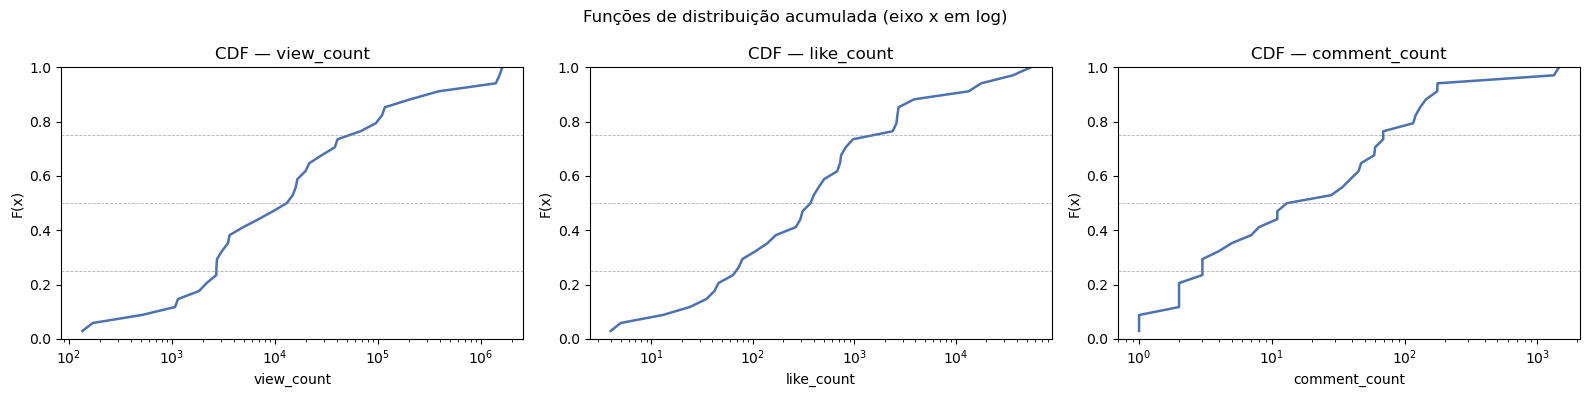

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['view_count', 'like_count', 'comment_count']):
    data = np.sort(df[col].replace(0, np.nan).dropna().values)
    if data.size == 0:
        ax.set_title(f'{col} (sem dados)')
        continue
    cdf = np.arange(1, data.size + 1) / data.size
    ax.plot(data, cdf, color='#4C72B0', lw=1.8)
    ax.set_xscale('log')
    ax.set_ylim(0, 1)
    ax.set_xlabel(col)
    ax.set_ylabel('F(x)')
    for q in (0.25, 0.5, 0.75):
        ax.axhline(q, color='grey', ls='--', lw=0.6, alpha=0.6)
    ax.set_title(f'CDF — {col}')
fig.suptitle('Funções de distribuição acumulada (eixo x em log)')
fig.tight_layout()
fig.savefig(f'{outdir}/cdf.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.2 Matriz de correlação

Como as variáveis são de cauda longa, aplicamos `log1p` antes de calcular a correlação de Pearson. O mapa de calor mostra quais métricas crescem juntas (valores próximos de **+1**, em vermelho) ou em sentidos opostos (próximos de **-1**, em azul).

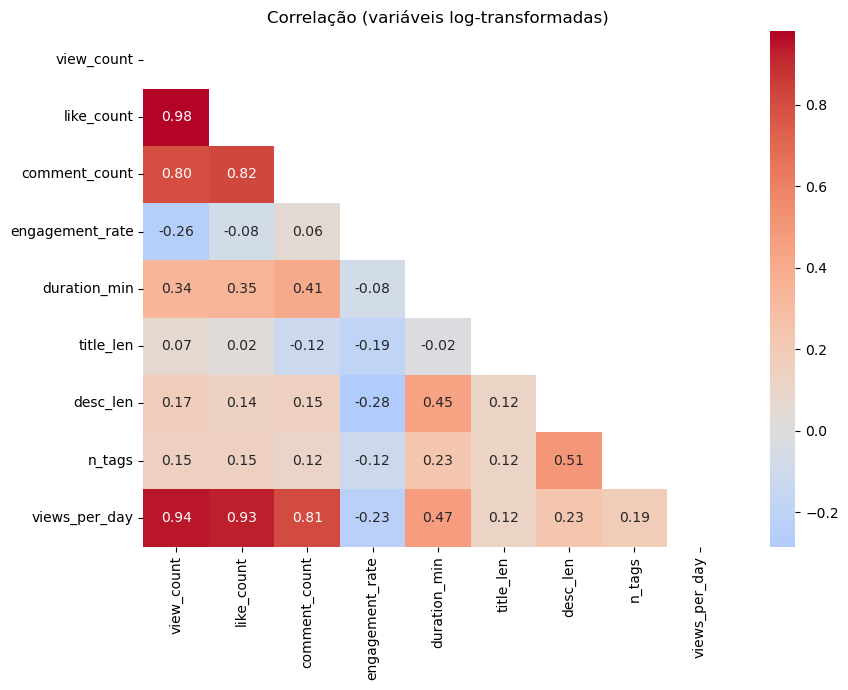

In [13]:
num_cols = [
    'view_count', 'like_count', 'comment_count', 'engagement_rate',
    'duration_min', 'title_len', 'desc_len', 'n_tags', 'views_per_day',
]
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].apply(lambda s: np.log1p(s) if s.min() >= 0 else s).corr()

# Máscara que esconde o triângulo SUPERIOR (mantém só o inferior)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlação (variáveis log-transformadas)')
fig.tight_layout()
fig.savefig(f'{outdir}/correlacao.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.3 Engajamento por dia da publicação

Um *boxplot* por dia da semana ajuda a ver se o dia em que o vídeo foi publicado tem relação com a taxa de engajamento. O eixo y está em escala logarítmica e os *outliers* foram omitidos para facilitar a leitura.

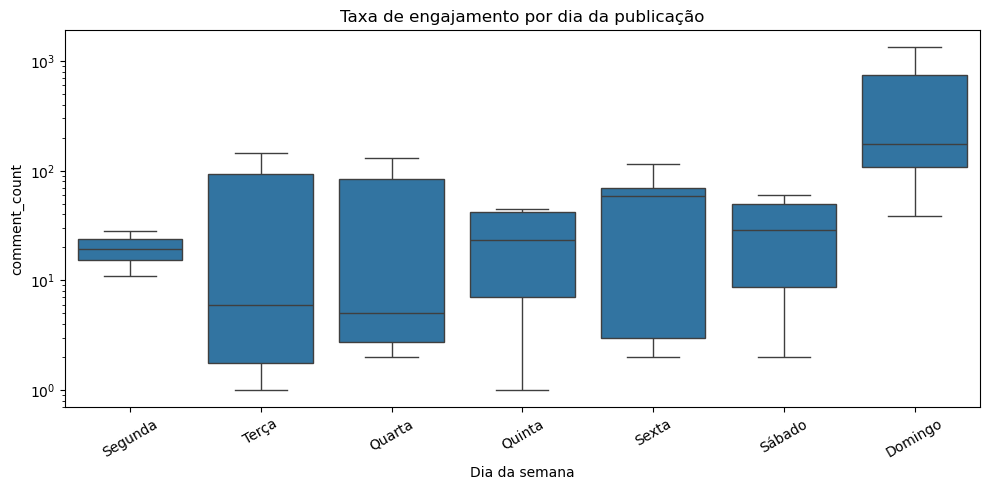

In [14]:
if 'pub_dow' in df.columns:
    order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    labels_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x='pub_dow', y='comment_count', order=order, showfliers=False, ax=ax)
    ax.set_title('Taxa de engajamento por dia da publicação')
    ax.set_xlabel('Dia da semana')
    ax.set_yscale('log')
    ax.set_xticks(range(len(labels_pt)))
    ax.set_xticklabels(labels_pt, rotation=30)
    fig.tight_layout()
    fig.savefig(f'{outdir}/engaj_por_dia3.png', dpi=120, bbox_inches='tight')
    plt.show()

### 6.4 Duração vs. engajamento

Gráfico de dispersão entre a duração do vídeo (em minutos, limitado a até 120 min) e a taxa de engajamento. Serve para investigar se vídeos mais curtos ou mais longos tendem a engajar mais.

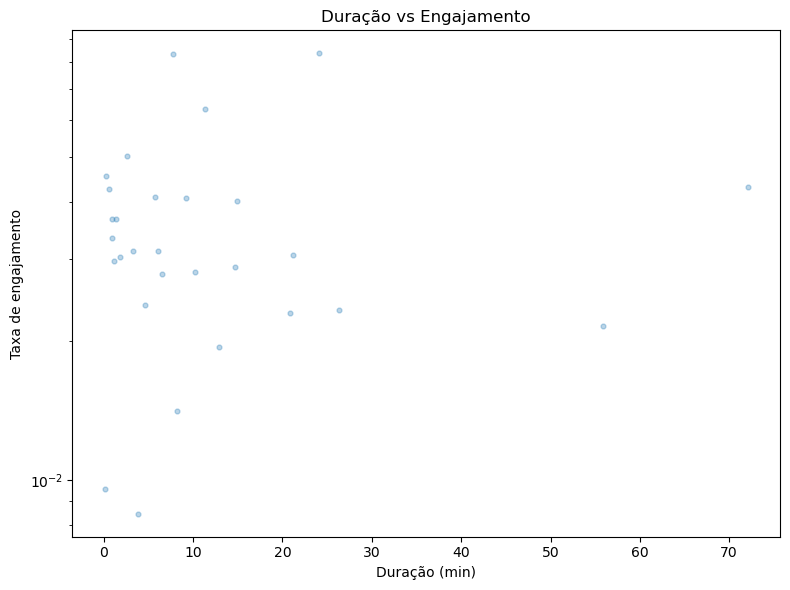

In [15]:
if 'duration_min' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    sub = df[(df['duration_min'] > 0) & (df['duration_min'] < 120)]
    ax.scatter(sub['duration_min'], sub['engagement_rate'], alpha=0.3, s=12)
    ax.set_xlabel('Duração (min)')
    ax.set_ylabel('Taxa de engajamento')
    ax.set_yscale('log')
    ax.set_title('Duração vs Engajamento')
    fig.tight_layout()
    fig.savefig(f'{outdir}/duracao_vs_engaj.png', dpi=120, bbox_inches='tight')
    plt.show()

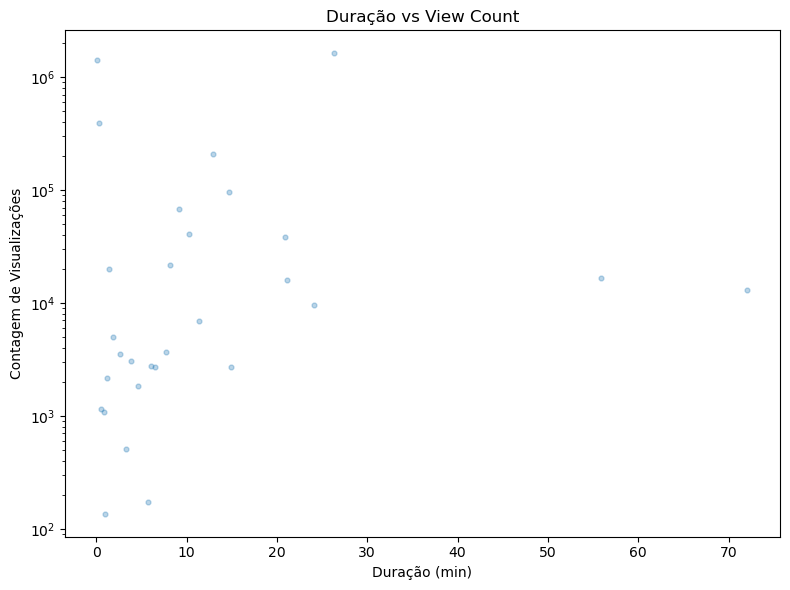

In [16]:
if 'duration_min' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    sub = df[(df['duration_min'] > 0) & (df['duration_min'] < 120)]
    ax.scatter(sub['duration_min'], sub['view_count'], alpha=0.3, s=12)
    ax.set_xlabel('Duração (min)')
    ax.set_ylabel('Contagem de Visualizações')
    ax.set_yscale('log')
    ax.set_title('Duração vs View Count')
    fig.tight_layout()
    fig.savefig(f'{outdir}/duracao_vs_view_count.png', dpi=120, bbox_inches='tight')
    plt.show()

### 6.5 Análise temporal: agregados por ano

Para olhar a evolução ao longo do tempo, agrupamos os vídeos por **ano de publicação** e calculamos totais e medianas. A tabela `yearly` abaixo será reutilizada nos próximos gráficos.

In [17]:
yearly = (
    df.dropna(subset=['pub_year'])
      .groupby(df['pub_year'].astype('Int64'))
      .agg(
          n_videos=('video_id', 'count'),
          total_views=('view_count', 'sum'),
          total_comments=('comment_count', 'sum'),
          median_views=('view_count', 'median'),
          median_views_per_day=('views_per_day', 'median'),
      )
      .sort_index()
)

print('=== Agregados anuais ===')
yearly

=== Agregados anuais ===


,n_videos,total_views,total_comments,median_views,median_views_per_day
pub_year,,,,,
2025,23,5570078,3545,13101.0,56.414696
2026,11,227552,636,14981.0,134.854514


#### 6.6 Volume de vídeos publicados por ano

Quantidade de vídeos criados em cada ano. O número sobre cada barra indica o total exato.

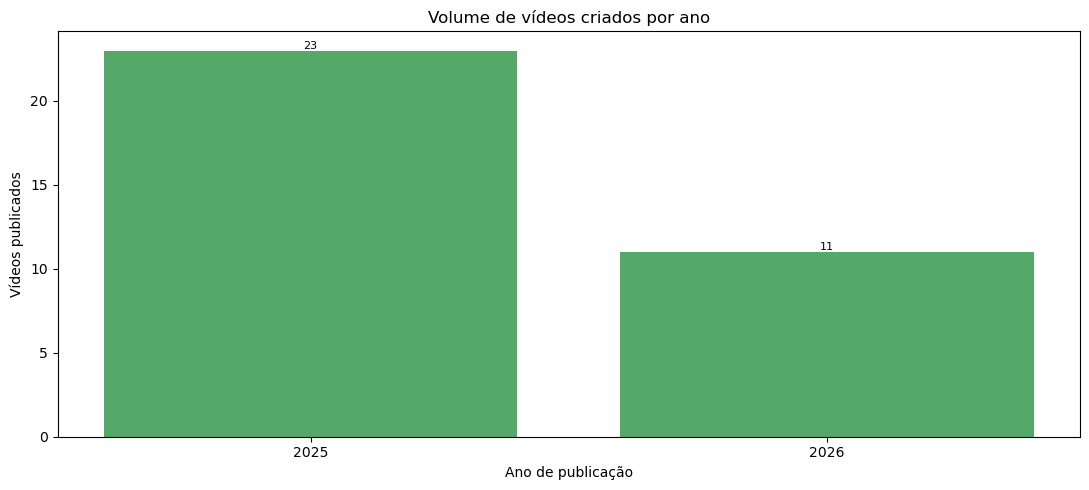

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(yearly.index.astype(str), yearly['n_videos'], color='#55A868')
ax.set_xlabel('Ano de publicação')
ax.set_ylabel('Vídeos publicados')
ax.set_title('Volume de vídeos criados por ano')
for i, v in enumerate(yearly['n_videos']):
    ax.text(i, v, f'{int(v)}', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(f'{outdir}/videos_por_ano.png', dpi=120, bbox_inches='tight')
plt.show()

#### 6.7 Views e comentários totais por ano

Gráfico de **eixos duplos**: as barras (azul) mostram as views totais e a linha (vermelho) mostra os comentários totais, permitindo comparar as duas grandezas mesmo com escalas diferentes.

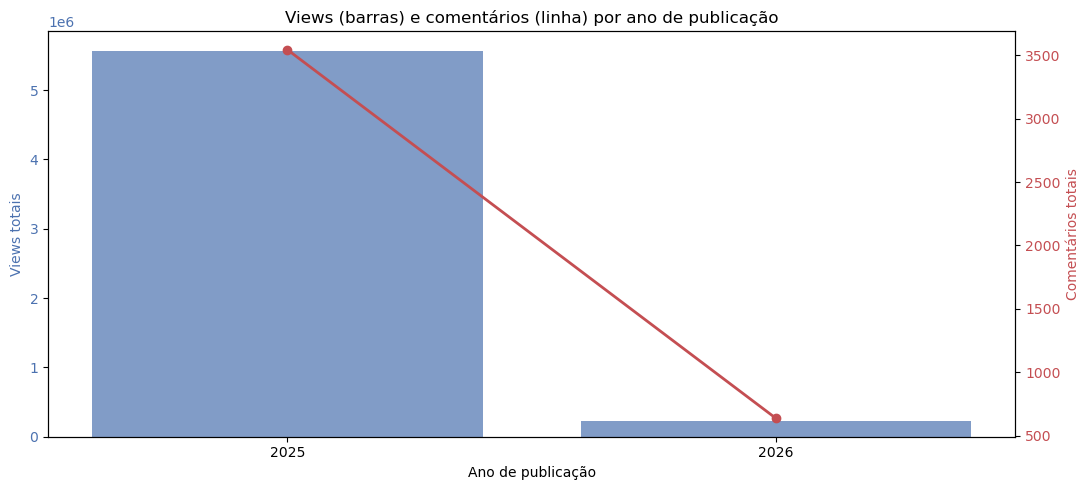

In [19]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(yearly.index.astype(str), yearly['total_views'], color='#4C72B0', alpha=0.7)
ax1.set_xlabel('Ano de publicação')
ax1.set_ylabel('Views totais', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(yearly.index.astype(str), yearly['total_comments'], color='#C44E52', marker='o', lw=2)
ax2.set_ylabel('Comentários totais', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

ax1.set_title('Views (barras) e comentários (linha) por ano de publicação')
fig.tight_layout()
fig.savefig(f'{outdir}/views_comentarios_por_ano.png', dpi=120, bbox_inches='tight')
plt.show()

#### 6.8 Mediana de views por vídeo ao longo dos anos

A **mediana** evita o viés dos totais (anos com mais vídeos somam mais views). Aqui vemos o desempenho típico de um vídeo em cada ano.

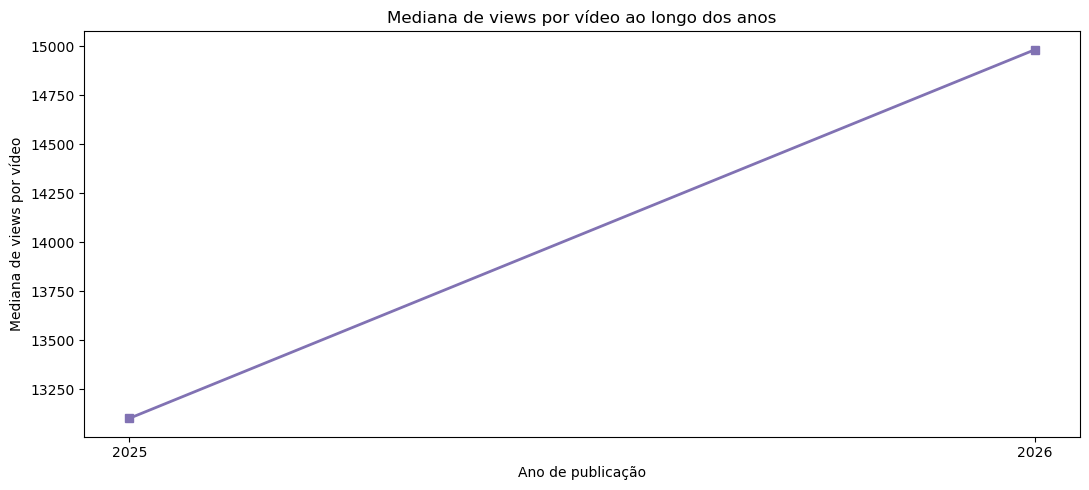

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly.index.astype(str), yearly['median_views'], color='#8172B3', marker='s', lw=2)
ax.set_xlabel('Ano de publicação')
ax.set_ylabel('Mediana de views por vídeo')
ax.set_title('Mediana de views por vídeo ao longo dos anos')
fig.tight_layout()
fig.savefig(f'{outdir}/mediana_views_por_ano.png', dpi=120, bbox_inches='tight')
plt.show()

#### 6.9 Mediana de views/dia por ano (normalizado pela idade)

Vídeos antigos tiveram mais tempo para acumular views. Dividindo pelas idades, a métrica **views/dia** compara coortes de forma mais justa entre anos diferentes.

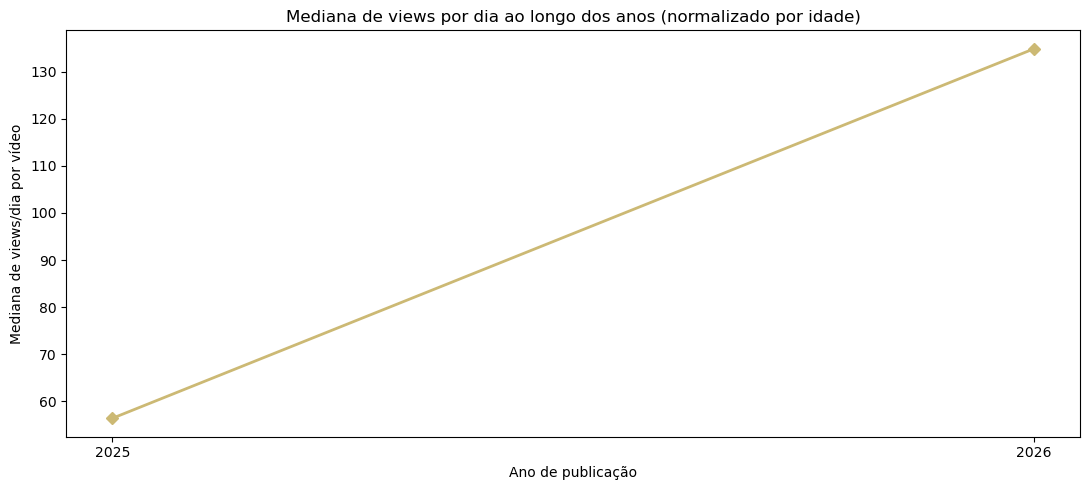

In [21]:
if 'median_views_per_day' in yearly.columns:
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(yearly.index.astype(str), yearly['median_views_per_day'], color='#CCB974', marker='D', lw=2)
    ax.set_xlabel('Ano de publicação')
    ax.set_ylabel('Mediana de views/dia por vídeo')
    ax.set_title('Mediana de views por dia ao longo dos anos (normalizado por idade)')
    fig.tight_layout()
    fig.savefig(f'{outdir}/views_por_dia_por_ano.png', dpi=120, bbox_inches='tight')
    plt.show()

#### 6.10 Vídeos publicados por mês (tendência fina)

Reamostrando por mês (`resample('ME')`), conseguimos uma visão mais detalhada da cadência de publicação ao longo do tempo do que o agregado anual.

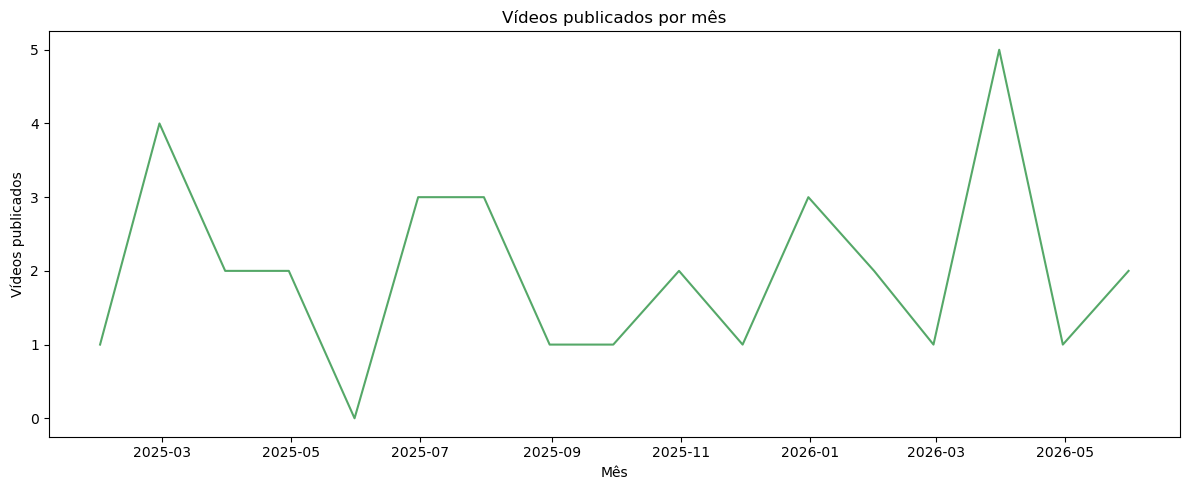

In [22]:
if 'published_at' in df.columns:
    monthly = (
        df.dropna(subset=['published_at'])
          .set_index('published_at')
          .resample('ME')['video_id']
          .count()
    )
    if not monthly.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(monthly.index, monthly.values, color='#55A868', lw=1.5)
        ax.set_xlabel('Mês')
        ax.set_ylabel('Vídeos publicados')
        ax.set_title('Vídeos publicados por mês')
        fig.tight_layout()
        fig.savefig(f'{outdir}/videos_por_mes.png', dpi=120, bbox_inches='tight')
        plt.show()

## 7. Comparações por grupo

Por fim, comparamos a taxa de engajamento entre categorias. A função `group_comparison` calcula mediana, média e contagem da métrica para cada valor de uma coluna categórica.

In [23]:
#Comparações de grupo (ex.: legenda, definição)
# ---------------------------------------------------------------------------
def group_comparison(df, by, metric="engagement_rate"):
    #Mediana e contagem da métrica por grupo categórico
    if by not in df.columns:
        print(f"Coluna '{by}' não encontrada.")
        return None
    g = df.groupby(by)[metric].agg(["median", "mean", "count"]).sort_values("median", ascending=False)
    print(f"=== {metric} por {by} ===")
    print(g)
    return g

### 7.1 Engajamento por presença de legenda (`caption`)

In [24]:
g_caption = group_comparison(dfvideos_filtrado, "caption")

=== engagement_rate por caption ===
           median      mean  count
caption                           
False    0.030534  0.034151     30
True     0.027114  0.034289      4


### 7.2 Engajamento por definição de vídeo (`definition` — SD vs HD)

In [25]:
g_definition = group_comparison(dfvideos_filtrado, "definition")

=== engagement_rate por definition ===
              median      mean  count
definition                           
hd          0.030668  0.034551     33
sd          0.021487  0.021487      1


### 7.3 Engajamento por categoria do vídeo (`category_id`)

Como há muitas categorias, exibimos a tabela ordenada pela mediana de engajamento.

In [26]:
g_categoria = group_comparison(dfvideos_filtrado, "category_id")
g_categoria

=== engagement_rate por category_id ===
               median      mean  count
category_id                           
28           0.040549  0.043165      8
22           0.036548  0.036548      2
24           0.029762  0.029762      1
27           0.028914  0.031022     23


,median,mean,count
category_id,,,
28,0.040549,0.043165,8
22,0.036548,0.036548,2
24,0.029762,0.029762,1
27,0.028914,0.031022,23


## Observação

Cada etapa acima produz uma saída isolada — tabela ou gráfico — facilitando entender o que cada transformação e cada visualização revelam sobre os dados. As figuras também ficam salvas em `figs/` no Drive para uso em relatórios.